In [1]:
import os
import re
import h5py
import numpy as np
import pandas as pd

from scipy.signal import butter, filtfilt, resample_poly, find_peaks
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

In [2]:
dirs = [
    r"D:\BLA_ChR_resp\BLA_resp_ChR_bl_cc\h5_outputs",
    r"D:\BLA_ChR_resp\BLA_resp_ChR_cm_hc\h5_outputs",
    r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs"
]

h5_files = []

for d in dirs:
    files = [os.path.join(d, f) for f in os.listdir(d) if f.endswith(".h5")]
    print(f"{d} → {len(files)} files")
    h5_files.extend(files)

h5_files = sorted(list(set(h5_files)))

print("TOTAL:", len(h5_files))

D:\BLA_ChR_resp\BLA_resp_ChR_bl_cc\h5_outputs → 22 files
D:\BLA_ChR_resp\BLA_resp_ChR_cm_hc\h5_outputs → 24 files
E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs → 8 files
TOTAL: 54


In [32]:
aim1_files = [f for f in h5_files if "Aim1" in f]

bla_files = [
    f for f in h5_files
    if "BLA_resp_ChR" in f  # catches BOTH bl_cc and cm_hc
]

print("AIM1:", len(aim1_files))
print("BLA CM:", len(bla_files))

AIM1: 8
BLA CM: 46


In [4]:
rank_map = {
    "1_1": "Subordinate",
    "1_2": "Dominant",
    "2_3": "Subordinate",
    "2_4": "Dominant",
    "3_5": "Subordinate",
    "3_6": "Dominant",
    "4_7": "Subordinate",
    "4_8": "Dominant"
}

rank_map_bla = {
    "1_1": "Intermediate", "1_2": "Dominant", "1_3": "Subordinate",
    "2_1": "Dominant", "2_2": "Subordinate", "2_3": "Intermediate",
    "3_1": "Intermediate", "3_2": "Dominant", "3_3": "Subordinate",
    "4_1": "Subordinate", "4_2": "Dominant", "4_3": "Dominant",
    "5_1": "Intermediate", "5_2": "Dominant", "5_3": "Subordinate",
    "6_2": "Dominant", "6_3": "Subordinate",
    "7_1": "Dominant", "7_2": "Subordinate",
    "8_1": "Dominant", "8_2": "Subordinate"
}

In [41]:
subjects_from_files = set()

for f in bla_files:
    trial = os.path.basename(f).replace(".h5", "")
    
    m = re.match(r"(\d+)[_.](\d+)", trial)
    if m:
        subj = f"{m.group(1)}_{m.group(2)}"
        subjects_from_files.add(subj)
    else:
        print("❌ parse fail:", trial)

print("Subjects in files:", len(subjects_from_files))
print(sorted(subjects_from_files))

Subjects in files: 23
['1_1', '1_2', '1_3', '2_1', '2_2', '2_3', '3_1', '3_2', '3_3', '4_1', '4_2', '4_3', '5_1', '5_2', '5_3', '6_2', '6_3', '7_1', '7_2', '7_3', '8_1', '8_2', '8_3']


In [5]:
def load_clean_resp_signal(h5_file, target_rate=100):

    with h5py.File(h5_file, 'r') as f:
        keys = list(f.keys())

        # BLA
        if "resp_clean" in keys:
            signal = f["resp_clean"]["signal"][:]
            time = f["resp_clean"]["time"][:]
            return signal, time, target_rate

        # AIM1
        elif "resp" in keys:
            resp = f["resp"][:].flatten()

            fs = 20000.0
            nyquist = fs / 2
            cutoff = target_rate / 2

            b, a = butter(4, cutoff / nyquist, btype='low')
            filtered = filtfilt(b, a, resp)

            down = resample_poly(filtered, up=1, down=int(fs / target_rate))
            time = np.arange(len(down)) / target_rate

            return down, time, target_rate

    return None, None, None

In [27]:
def extract_breathmetrics_features(signal, time, fs=100):

    peaks, _ = find_peaks(signal, distance=int(fs * 0.08))

    if len(peaks) < 5:
        return None

    peak_times = time[peaks]
    ibi = np.diff(peak_times)

    if len(ibi) < 3:
        return None

    rate = 1 / ibi

    peak_vals = signal[peaks]

    inhale_vol = []
    exhale_vol = []
    inhale_dur = []

    for i in range(len(peaks)-1):
        start = peaks[i]
        end = peaks[i+1]

        seg = signal[start:end]
        if len(seg) < 3:
            continue

        inh = np.max(seg) - seg[0]
        exh = np.max(seg) - seg[-1]

        inhale_vol.append(inh)
        exhale_vol.append(exh)
        inhale_dur.append((end - start) / fs)

    inhale_vol = np.array(inhale_vol)
    exhale_vol = np.array(exhale_vol)
    inhale_dur = np.array(inhale_dur)

    if len(inhale_vol) < 3:
        return None

    tidal_vol = inhale_vol + exhale_vol
    duty_cycle = inhale_dur / ibi[:len(inhale_dur)]

    feats = {}

    feats["BreathingRate"] = np.mean(rate)
    feats["Rate_CV"] = np.std(rate) / np.mean(rate)

    feats["IBI_mean"] = np.mean(ibi)
    feats["IBI_std"] = np.std(ibi)

    feats["InhaleVol_mean"] = np.mean(inhale_vol)
    feats["ExhaleVol_mean"] = np.mean(exhale_vol)
    feats["TidalVol_mean"] = np.mean(tidal_vol)

    feats["Vol_CV"] = np.std(tidal_vol) / np.mean(tidal_vol)

    feats["MinuteVent"] = feats["BreathingRate"] * feats["TidalVol_mean"]

    feats["DutyCycle_mean"] = np.mean(duty_cycle)
    feats["DutyCycle_CV"] = np.std(duty_cycle) / np.mean(duty_cycle)

    return feats

In [33]:
rows = []

for h5_path in aim1_files + bla_files:

    trial = os.path.basename(h5_path).replace(".h5", "")

    signal, time, fs = load_clean_resp_signal(h5_path)
    if signal is None:
        continue

    # -------------------------
    # parse subject + partner
    # -------------------------
    subject = None
    partner = None

    if "Aim1" in h5_path:

        subj = re.search(r"s(\d+)_(\d+)", trial)
        part = re.search(r"(?:d|sub)(\d+)_(\d+)", trial)

        if subj:
            subject = f"{subj.group(1)}_{subj.group(2)}"
        if part:
            partner = f"{part.group(1)}_{part.group(2)}"

        rank = rank_map.get(subject, np.nan)

    else:
        parts = trial.split("_")

        subject = f"{parts[0]}_{parts[1]}"
        if len(parts) >= 6:
            partner = f"{parts[4]}_{parts[5]}"

        rank = rank_map_bla.get(subject, np.nan)
    if "Aim1" in h5_path:
        cohort = "AIM1"
    else:
        cohort = "BLA"

    # -------------------------
    # windowing (100 windows)
    # -------------------------
    win = int(2 * fs)
    starts = np.arange(0, len(signal) - win, win)

    for s in starts[:100]:

        seg = signal[s:s+win]
        seg_time = time[s:s+win]

        feats = extract_breathmetrics_features(seg, seg_time, fs)

        if feats is None:
            continue

        feats["Subject"] = f"{subject}_{cohort}"
        feats["Subject_raw"] = subject
        feats["Rank"] = rank

        rows.append(feats)

df_feat = pd.DataFrame(rows)

print(df_feat.shape)
df_feat.head()

(5360, 14)


,BreathingRate,Rate_CV,IBI_mean,IBI_std,InhaleVol_mean,ExhaleVol_mean,TidalVol_mean,Vol_CV,MinuteVent,DutyCycle_mean,DutyCycle_CV,Subject,Subject_raw,Rank
0,7.062855,0.397703,0.164167,0.058375,198.243378,120.411039,318.654417,0.515341,2250.610062,1.0,5.706230e-16,1_1_AIM1,1_1,Subordinate
1,9.306070,0.138003,0.109412,0.014337,73.336238,226.729926,300.066164,0.428775,2792.436649,1.0,1.928046e-15,1_1_AIM1,1_1,Subordinate
2,9.014593,0.203763,0.117500,0.034004,64.059988,234.322694,298.382682,0.822464,2689.798586,1.0,2.750044e-15,1_1_AIM1,1_1,Subordinate
3,10.090588,0.162393,0.103333,0.027487,95.494554,357.589230,453.083784,1.055290,4571.881990,1.0,4.054975e-15,1_1_AIM1,1_1,Subordinate
4,10.488636,0.082747,0.096000,0.008000,53.045486,266.126639,319.172125,0.476792,3347.680360,1.0,5.728095e-15,1_1_AIM1,1_1,Subordinate


In [43]:
print(df_feat["Subject"].unique()[:])
print(df_feat["Subject_raw"].unique())

['1_1_AIM1' '1_2_AIM1' '2_3_AIM1' '2_4_AIM1' '3_5_AIM1' '3_6_AIM1'
 '4_7_AIM1' '4_8_AIM1' '1_1_BLA' '1_2_BLA' '1_3_BLA' '2_1_BLA' '2_2_BLA'
 '2_3_BLA' '3_1_BLA' '3_2_BLA' '3_3_BLA' '4_1_BLA' '4_2_BLA' '4_3_BLA'
 '5_1_BLA' '5_2_BLA' '5_3_BLA' '6_3_BLA' '7_1_BLA' '7_2_BLA' '7_3_BLA'
 '8_1_BLA' '8_2_BLA' '8_3_BLA' '6_2_BLA']
['1_1' '1_2' '2_3' '2_4' '3_5' '3_6' '4_7' '4_8' '1_3' '2_1' '2_2' '3_1'
 '3_2' '3_3' '4_1' '4_2' '4_3' '5_1' '5_2' '5_3' '6_3' '7_1' '7_2' '7_3'
 '8_1' '8_2' '8_3' '6_2']


In [46]:
print("Subjects:", df_feat["Subject_raw"].nunique())
print(sorted(df_feat["Subject_raw"].unique()))
print(df_feat["Rank"].value_counts())

Subjects: 28
['1_1', '1_2', '1_3', '2_1', '2_2', '2_3', '2_4', '3_1', '3_2', '3_3', '3_5', '3_6', '4_1', '4_2', '4_3', '4_7', '4_8', '5_1', '5_2', '5_3', '6_2', '6_3', '7_1', '7_2', '7_3', '8_1', '8_2', '8_3']
Rank
Subordinate     2092
Dominant        2074
Intermediate     994
Name: count, dtype: int64


In [44]:
print(sorted(df_feat["Subject_raw"].unique()))
print(len(df_feat["Subject_raw"].unique()))

['1_1', '1_2', '1_3', '2_1', '2_2', '2_3', '2_4', '3_1', '3_2', '3_3', '3_5', '3_6', '4_1', '4_2', '4_3', '4_7', '4_8', '5_1', '5_2', '5_3', '6_2', '6_3', '7_1', '7_2', '7_3', '8_1', '8_2', '8_3']
28


In [45]:
len(bla_files)
df_feat["Subject_raw"].unique()

array(['1_1', '1_2', '2_3', '2_4', '3_5', '3_6', '4_7', '4_8', '1_3',
       '2_1', '2_2', '3_1', '3_2', '3_3', '4_1', '4_2', '4_3', '5_1',
       '5_2', '5_3', '6_3', '7_1', '7_2', '7_3', '8_1', '8_2', '8_3',
       '6_2'], dtype=object)

In [50]:
df_feat = df_feat[df_feat["Rank"].isin(["Dominant","Subordinate"])].copy()

In [51]:
print("Subjects:", df_feat["Subject_raw"].nunique())
print(sorted(df_feat["Subject_raw"].unique()))
print(df_feat["Rank"].value_counts())

Subjects: 24
['1_1', '1_2', '1_3', '2_1', '2_2', '2_3', '2_4', '3_2', '3_3', '3_5', '3_6', '4_1', '4_2', '4_3', '4_7', '4_8', '5_2', '5_3', '6_2', '6_3', '7_1', '7_2', '8_1', '8_2']
Rank
Subordinate    2092
Dominant       2074
Name: count, dtype: int64


In [52]:
df_all = df_feat.copy()

In [53]:
df_all = df_all[df_all["Rank"].isin(["Dominant","Subordinate"])].copy()

In [54]:
df_subj = df_all.groupby("Subject").mean(numeric_only=True)
df_subj["Rank"] = df_all.groupby("Subject")["Rank"].first()

print(df_subj.shape)

(25, 12)


In [57]:
feature_cols = [
    "BreathingRate",
    "Rate_CV",
    "IBI_mean",
    "IBI_std",
    "InhaleVol_mean",
    "ExhaleVol_mean",
    "TidalVol_mean",
    "Vol_CV",
    "MinuteVent",
    "DutyCycle_mean",
    "DutyCycle_CV"
]

X = df_subj[feature_cols].to_numpy()
y = (df_subj["Rank"] == "Dominant").astype(int).to_numpy()

In [59]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

aucs = []

for train_idx, test_idx in cv.split(X, y):

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", probability=True))
    ])

    model.fit(X[train_idx], y[train_idx])
    y_pred = model.predict_proba(X[test_idx])[:,1]

    auc = roc_auc_score(y[test_idx], y_pred)
    aucs.append(auc)

print(f"\nCOMBINED AUC: {np.mean(aucs):.2f} ± {np.std(aucs)/np.sqrt(len(aucs)):.2f}")


COMBINED AUC: 0.63 ± 0.07


In [60]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

aucs = []

for train_idx, test_idx in cv.split(X, y):

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", probability=True))
    ])

    model.fit(X[train_idx], y[train_idx])
    y_pred = model.predict_proba(X[test_idx])[:,1]

    auc = roc_auc_score(y[test_idx], y_pred)
    aucs.append(auc)

print(f"\nCOMBINED AUC: {np.mean(aucs):.2f} ± {np.std(aucs)/np.sqrt(len(aucs)):.2f}")


COMBINED AUC: 0.63 ± 0.07


In [62]:
# -------------------------
# Subject-level averages
# -------------------------
df_rate = (
    df_feat[df_feat["Rank"].isin(["Dominant","Subordinate"])]
    .groupby("Subject")
    .agg({
        "BreathingRate": "mean",
        "Rate_CV": "mean",
        "Rank": "first"
    })
    .reset_index()
)

print(df_rate)

     Subject  BreathingRate   Rate_CV         Rank
0   1_1_AIM1       6.990243  0.173217  Subordinate
1   1_2_AIM1       7.354264  0.245821     Dominant
2    1_2_BLA       8.984945  0.205687     Dominant
3    1_3_BLA       9.069437  0.213844  Subordinate
4    2_1_BLA       9.461266  0.212624     Dominant
5    2_2_BLA       9.770671  0.199909  Subordinate
6   2_3_AIM1       8.429801  0.241874  Subordinate
7   2_4_AIM1       5.910392  0.244601     Dominant
8    3_2_BLA       8.856847  0.263748     Dominant
9    3_3_BLA       9.461651  0.220848  Subordinate
10  3_5_AIM1       7.206278  0.264113  Subordinate
11  3_6_AIM1       5.086660  0.165086     Dominant
12   4_1_BLA       8.388475  0.244141  Subordinate
13   4_2_BLA       9.270236  0.230618     Dominant
14   4_3_BLA       9.425158  0.217893     Dominant
15  4_7_AIM1       7.462800  0.238428  Subordinate
16  4_8_AIM1       8.049019  0.262327     Dominant
17   5_2_BLA       8.610433  0.240836     Dominant
18   5_3_BLA       8.949209  0.

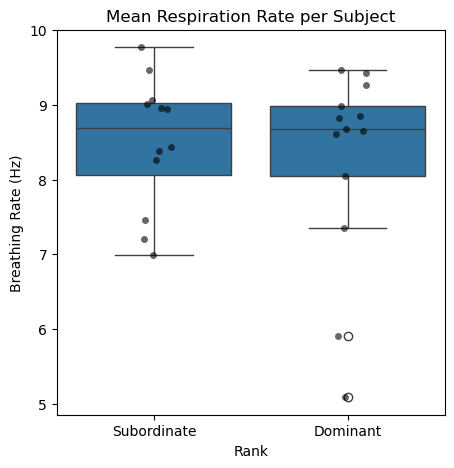

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
sns.boxplot(data=df_rate, x="Rank", y="BreathingRate")
sns.stripplot(data=df_rate, x="Rank", y="BreathingRate", color="black", alpha=0.6)

plt.title("Mean Respiration Rate per Subject")
plt.ylabel("Breathing Rate (Hz)")
plt.show()

C:\Users\sjs93\AppData\Local\Temp\ipykernel_36632\104325195.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_rate, x="Rank", y="BreathingRate", palette=palette)


<Axes: xlabel='Rank', ylabel='BreathingRate'>

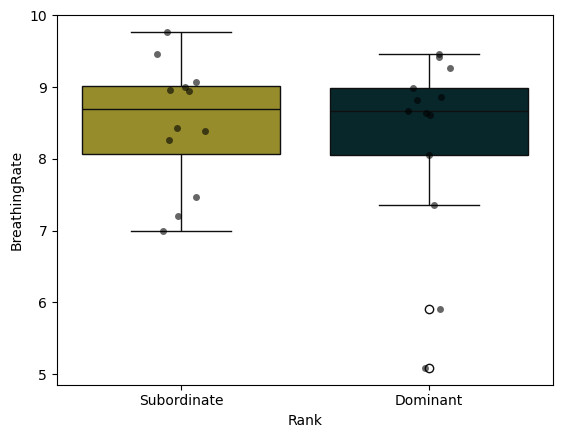

In [67]:
palette = {
    "Dominant": "#022C31",
    "Subordinate": "#A89A19"
}

sns.boxplot(data=df_rate, x="Rank", y="BreathingRate", palette=palette)
sns.stripplot(data=df_rate, x="Rank", y="BreathingRate", color="black", alpha=0.6)